**Break the Old Model**

Goal:

Show what happens when we choose a bad learning rate (too big or too small).


Instructions

Load the house price dataset (simple X vs Y).

Implement gradient descent with a fixed learning rate.

Try two cases:

Very small learning rate (0.001) → painfully slow.

Very large learning rate (0.75) → divergence.

Compare the results.

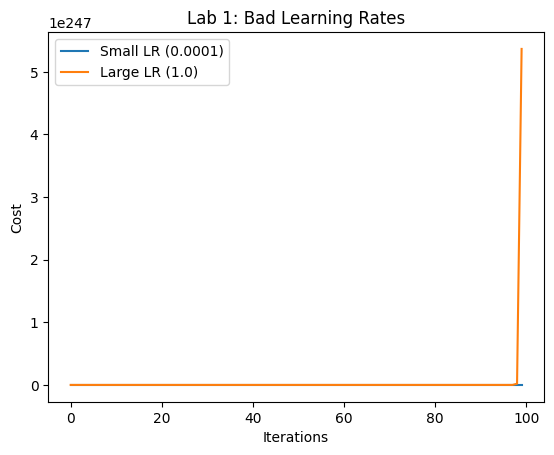

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated dataset (House size vs Price)
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([150, 300, 450, 600, 750], dtype=float)

# Gradient Descent with fixed learning rate
def gradient_descent(X, y, lr=0.01, iterations=50):
    m, c = 0, 0  # initial slope and intercept
    n = len(X)
    costs = []

    for _ in range(iterations):
        y_pred = m * X + c
        error = y_pred - y
        cost = np.mean(error ** 2)
        costs.append(cost)

        # Gradients
        dm = (2/n) * np.dot(error, X)
        dc = (2/n) * np.sum(error)

        # Update
        m -= lr * dm
        c -= lr * dc

    return m, c, costs

# Case 1: Too small LR
m1, c1, costs1 = gradient_descent(X, y, lr=0.01, iterations=100)
# Case 2: Too large LR
m2, c2, costs2 = gradient_descent(X, y, lr=0.75, iterations=100)

plt.plot(costs1, label="Small LR (0.0001)")
plt.plot(costs2, label="Large LR (1.0)")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Lab 1: Bad Learning Rates")
plt.legend()
plt.show()


Smart Backtracking Line

Goal:

Implement Backtracking Line Search so the algorithm chooses a good step size automatically.

Instructions

Start with a large step size guess.

If the new cost is lower → accept the step.

If the cost increases → shrink step by half, retry.

Observe how the algorithm adapts.

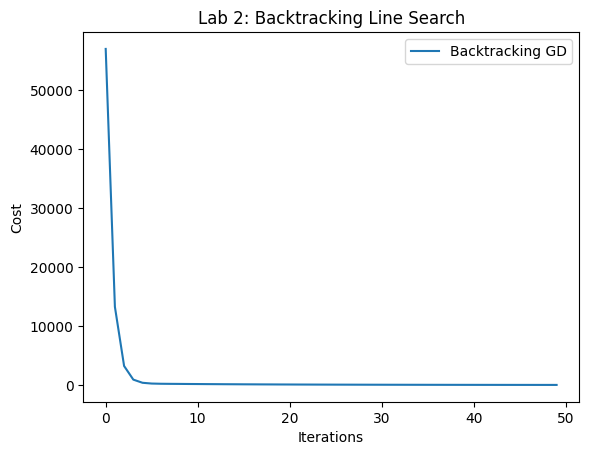

Final Model: y = 147.58x + 8.36


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset (House size vs Price)
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([150, 300, 450, 600, 750], dtype=float)

def compute_cost(X, y, m, c):
    y_pred = m * X + c
    return np.mean((y - y_pred) ** 2)

def gradient_descent_backtracking(X, y, initial_lr=1.0, iterations=150, shrink_factor=0.5):
    m, c = 0, 0
    n = len(X)
    costs = []

    for _ in range(iterations):
        y_pred = m * X + c
        error = y_pred - y

        # Gradients
        dm = (2/n) * np.dot(error, X)
        dc = (2/n) * np.sum(error)

        # Backtracking: find good step size
        step = initial_lr
        cost = compute_cost(X, y, m, c)
        while True:
            new_m = m - step * dm
            new_c = c - step * dc
            new_cost = compute_cost(X, y, new_m, new_c)

            if new_cost < cost:  # success, accept step
                m, c = new_m, new_c
                cost = new_cost
                break
            else:
                step *= shrink_factor  # reduce step size

        costs.append(cost)

    return m, c, costs

# Run Backtracking GD
m_bt, c_bt, costs_bt = gradient_descent_backtracking(X, y, initial_lr=1.0, iterations=50)

plt.plot(costs_bt, label="Backtracking GD")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Lab 2: Backtracking Line Search")
plt.legend()
plt.show()

print(f"Final Model: y = {m_bt:.2f}x + {c_bt:.2f}")
